# Computational Electrodynamics - 01

Pamudu_Amarasinghe

# 1) electrostatic potential on the symmetry axis of a uniformly charged square plate (neglecting the thickness of the plate)

# 2)

In [39]:
# gauss law
# inter (E.dA) = Q / Epsilon
p=1
e=8.854e-12
# V= Q / 4*pi*e*r

import numpy as np


def f(x,y,z):
    return 1 / np.sqrt(x**2 + y**2 + z**2)

def midpoint_int_3d(a, n):
    h = a / n
    total_sum = 0.0

    for i in range(n):
        x_mid = -a + h * i

        for j in range(n):
            y_mid = -a + h * j

            total_sum += f(x_mid+h/2, y_mid+h/2, a)

    return total_sum * (h ** 2),h

#V at (0,0,a)  a=1
intergration,_ = midpoint_int_3d(1,100)
V = intergration* (1/4*np.pi*e)
print("Integration value = ",intergration)
print("Potential value =",V)


Integration value =  0.7933615269629969
Potential value = 5.5169688914991035e-12


# 3)

In [70]:
n_values = [10,50,100,500,1000]
h_values=[]
int_values=[]
print("Iterati|  h value   | intergration    | Pottential")
for n in n_values:
    intergration,h = midpoint_int_3d(1,n)
    V = intergration* (1/4*np.pi*e)
    h_values.append(h)
    int_values.append(intergration)
    print(f"{n:6d} | {h:10.4f} | {intergration:18.7e} | {V:18.7e}")


Iterati|  h value   | intergration    | Pottential
    10 |     0.1000 |      7.9359979e-01 |      5.5186257e-12
    50 |     0.0200 |      7.9336874e-01 |      5.5170191e-12
   100 |     0.0100 |      7.9336153e-01 |      5.5169689e-12
   500 |     0.0020 |      7.9335922e-01 |      5.5169528e-12
  1000 |     0.0010 |      7.9335915e-01 |      5.5169523e-12


# 4)

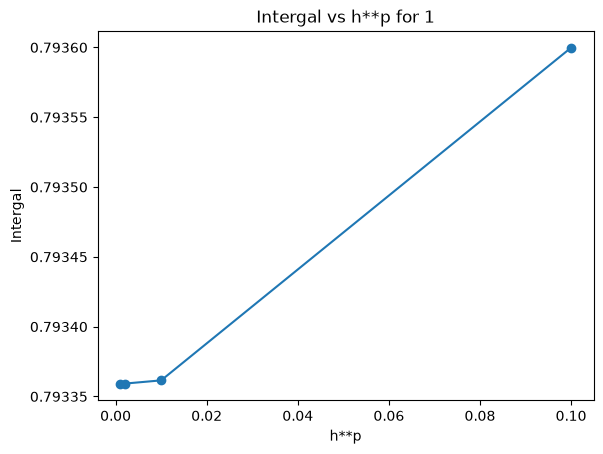

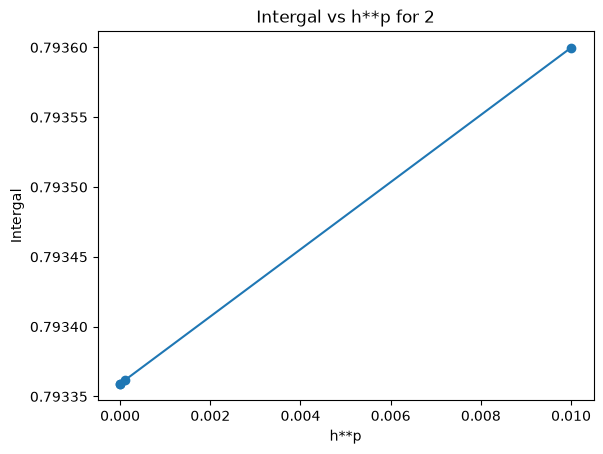

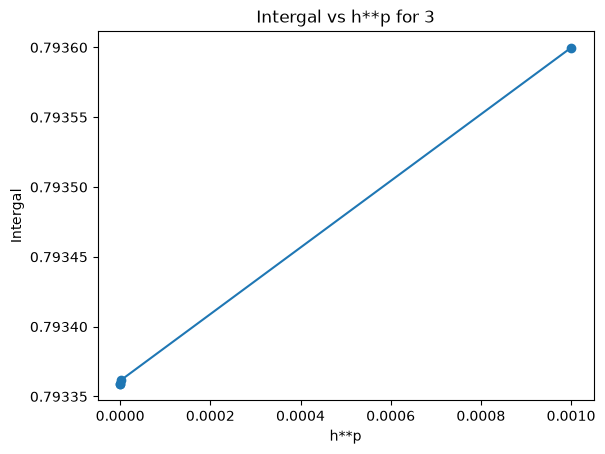

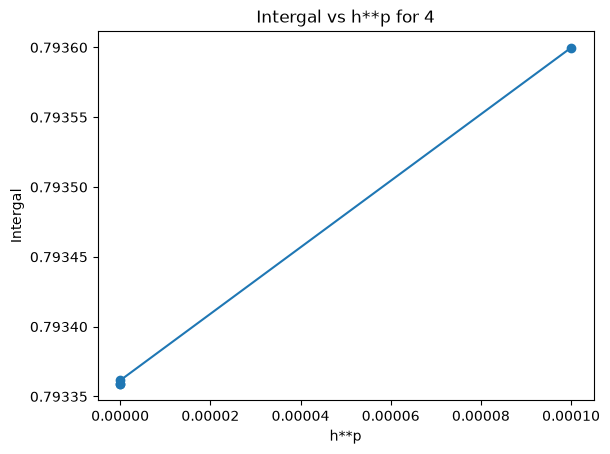

In [67]:
import matplotlib.pyplot as plt
#order of convergence
p_values=[1,2,3,4]
for p in p_values:
    h_P= [h**p for h in h_values]
    plt.scatter(h_P,int_values)
    plt.plot(h_P,int_values)
    plt.title(f"Intergal vs h**p for {p}")
    plt.xlabel("h**p")
    plt.ylabel("Intergal")
    plt.show()





p =2 is most linear

5)

In [81]:
#convergence estimate

for i in range(len(h_values) - 2):

    hi = h_values[i]
    hi1 = h_values[i + 1]
    hi2 = h_values[i + 2]

    Ii = int_values[i]
    Ii1 = int_values[i + 1]
    Ii2 = int_values[i + 2]

    p = np.log(abs((Ii - Ii1) / (Ii1 - Ii2))) / np.log(hi / hi1)

    print()
    print("hi   =", hi)
    print("hi+1 =", hi1)
    print("hi+2 =", hi2)
    print("p    =", p)


hi   = 0.1
hi+1 = 0.02
hi+2 = 0.01
p    = 2.1536470804960994

hi   = 0.02
hi+1 = 0.01
hi+2 = 0.002
p    = 1.643880788044278

hi   = 0.01
hi+1 = 0.002
hi+2 = 0.001
p    = 2.153385690239416


# 6)

# The value obtained from the graph ploting is p=2. from the convergence estimate equation we observe the value is reaching this value

# 7)

In [ ]:
print(int_values)
print(h_values)

I=np.array(int_values)
H=np.array(h_values)**2

m,c = np.polyfit(H,I,1)
I_fit = m * H + c

print("zero cell size extrapolated value =", c)

# 8) Simpson's rule - based integration

In [3]:
# gauss law
# inter (E.dA) = Q / Epsilon
p=1
e=8.854e-12
# V= Q / 4*pi*e*r

import numpy as np


def f(x,y,z):
    return 1 / np.sqrt(x**2 + y**2 + z**2)

def simpson_int_3d(a, n):

    h = a / n
    total_sum = 0.0

    for i in range(n):

        x = -a + h * i

        for j in range(n):

            y = -a + h * j

            total_sum += (
                f(x, y, a)
                + 4*f(x+h/2, y, a)
                + f(x+h, y, a)

                + 4*f(x, y+h/2, a)
                + 16*f(x+h/2, y+h/2, a)
                + 4*f(x+h, y+h/2, a)

                + f(x, y+h, a)
                + 4*f(x+h/2, y+h, a)
                + f(x+h, y+h, a)
            )

    return total_sum * (h ** 2 / 36), h

    integral = total_sum * h**2 / 9

    return integral, h


a = 1
n = 100

#V at (0,0,a)  a=1
intergration,_ = simpson_int_3d(1,100)
V = intergration* (1/4*np.pi*e)
print("Integration value = ",intergration)
print("Potential value =",V)


Integration value =  0.7933591213285285
Potential value = 5.516952162920674e-12


Iterati|  h value   | intergration    | Pottential
    10 |     0.1000 |      7.9335914e-01 |      5.5169523e-12
    50 |     0.0200 |      7.9335912e-01 |      5.5169522e-12
   100 |     0.0100 |      7.9335912e-01 |      5.5169522e-12
   500 |     0.0020 |      7.9335912e-01 |      5.5169522e-12
  1000 |     0.0010 |      7.9335912e-01 |      5.5169522e-12


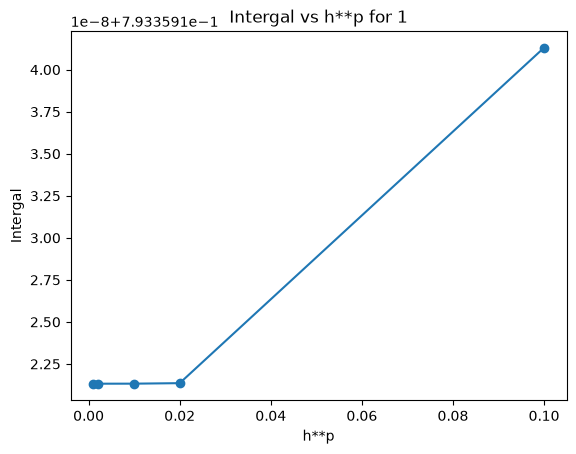

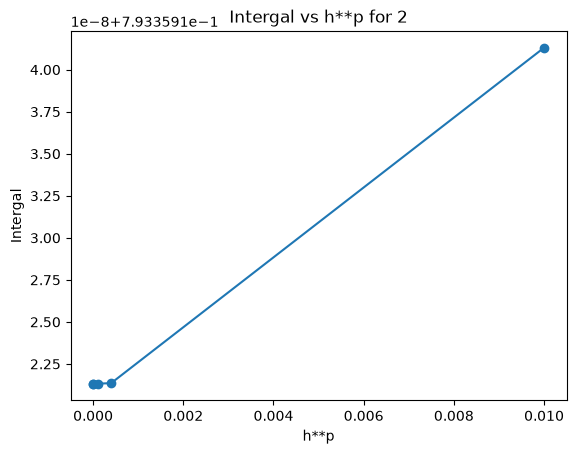

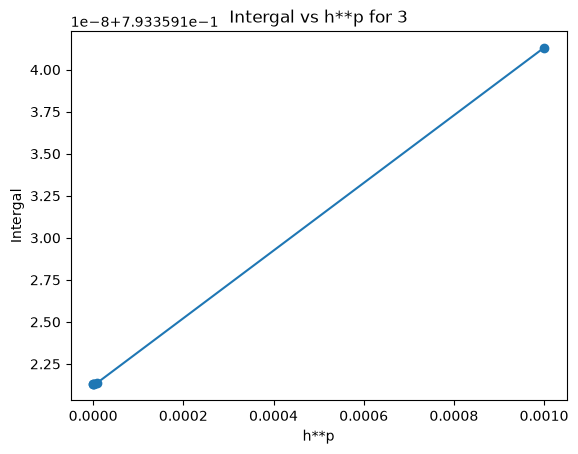

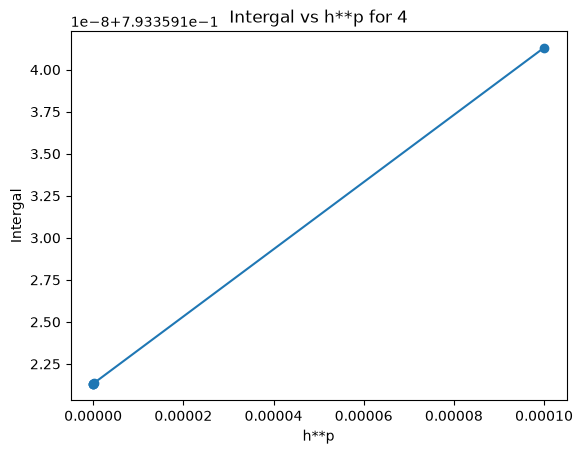


hi   = 0.1
hi+1 = 0.02
hi+2 = 0.01
p    = 4.037263060150513

hi   = 0.02
hi+1 = 0.01
hi+2 = 0.002
p    = 3.922356216416426

hi   = 0.01
hi+1 = 0.002
hi+2 = 0.001
p    = 2.6648736322147806


In [5]:
n_values = [10,50,100,500,1000]
h_values=[]
int_values=[]
print("Iterati|  h value   | intergration    | Pottential")
for n in n_values:
    intergration,h = simpson_int_3d(1,n)
    V = intergration* (1/4*np.pi*e)
    h_values.append(h)
    int_values.append(intergration)
    print(f"{n:6d} | {h:10.4f} | {intergration:18.7e} | {V:18.7e}")

import matplotlib.pyplot as plt
#order of convergence
p_values=[1,2,3,4]
for p in p_values:
    h_P= [h**p for h in h_values]
    plt.scatter(h_P,int_values)
    plt.plot(h_P,int_values)
    plt.title(f"Intergal vs h**p for {p}")
    plt.xlabel("h**p")
    plt.ylabel("Intergal")
    plt.show()


    #convergence estimate

for i in range(len(h_values) - 2):

    hi = h_values[i]
    hi1 = h_values[i + 1]
    hi2 = h_values[i + 2]

    Ii = int_values[i]
    Ii1 = int_values[i + 1]
    Ii2 = int_values[i + 2]

    p = np.log(abs((Ii - Ii1) / (Ii1 - Ii2))) / np.log(hi / hi1)

    print()
    print("hi   =", hi)
    print("hi+1 =", hi1)
    print("hi+2 =", hi2)
    print("p    =", p)

# 10)

In [ ]:
import numpy as np


def f(x,y):
    return 1 / np.sqrt(x**2 + y**2)

def midpoint_int_2d(a, n):  # z = 0
    h = a / n
    total_sum = 0.0

    for i in range(n):
        x_mid = -a + h * i

        for j in range(n):
            y_mid = -a + h * j

            total_sum += f(x_mid+h/2, y_mid+h/2)

    return total_sum * (h ** 2),h

def simpson_int_2d(a, n):

    h = a / n
    total_sum = 0.0

    for i in range(n):

        x = -a + h * i

        for j in range(n):

            y = -a + h * j

            total_sum += (
                f(x, y)
                + 4*f(x+h/2, y)
                + f(x+h, y)

                + 4*f(x, y+h/2)
                + 16*f(x+h/2, y+h/2)
                + 4*f(x+h, y+h/2)

                + f(x, y+h)
                + 4*f(x+h/2, y+h)
                + f(x+h, y+h)
            )

    return total_sum * (h ** 2 / 36), h

    integral = total_sum * h**2 / 9

    return integral, h

#analyical value 2 ln(1 + √2) = 1.762747
int_analytical = 1.762747
print("Analytical value =", int_analytical)

a= 1
n_values = [10,50,100,500,1000]

for n in n_values:
    int_mid,h_mid = midpoint_int_2d(a,n)
    diff_mid = abs(int_mid - int_analytical)
    print(f"n={n:4d} | Midpoint: int={int_mid:.7f}, h={h_mid:.4f}, diff={diff_mid:.7e} ")

print()

for n in n_values:
    int_simp,h_simp = simpson_int_2d(a,n)
    diff_simp = abs(int_simp - int_analytical)
    print(f"n={n:4d} | Simpson: int={int_simp:.7f}, h={h_simp:.4f}, diff={diff_simp:.7e} ")    

Analytical value = 1.762747
n=  10 | Midpoint: int=1.7229474, h=0.1000, diff=3.9799601e-02 
n=  50 | Midpoint: int=1.7546930, h=0.0200, diff=8.0539696e-03 
n= 100 | Midpoint: int=1.7587142, h=0.0100, diff=4.0327900e-03 
n= 500 | Midpoint: int=1.7619396, h=0.0020, diff=8.0736157e-04 
n=1000 | Midpoint: int=1.7623433, h=0.0010, diff=4.0365269e-04 

n=  10 | Simpson:  int=2248736.8631283, h=0.2000, diff=2.2487351e+06 
n=  50 | Simpson:  int=89956.0885573, h=0.0400, diff=8.9954326e+04 
n= 100 | Simpson:  int=5628.8115762, h=0.0200, diff=5.6270488e+03 
n= 500 | Simpson:  int=231.9107940, h=0.0040, diff=2.3014805e+02 
n=1000 | Simpson:  int=63.2626218, h=0.0020, diff=6.1499875e+01 


# 11) 
By comparison the mid point intigrations has the highest accuracy and computational compatibility with singular point integrand,
Simpson's rule, however, requires evaluating the function at the endpoints: f(0,0) which will tend to blow up